- # **Install emantis from PyPI via pip:**

In [1]:
pip install emantis

- # **Train emulators once, then reuse.**


In [22]:
!emantis-train

Will train all emulators using 2 processes.

----- Train matter_power_spectrum emulators -----

e-MANTIS:sigma8:LCDM: Training the emulator...
e-MANTIS:sigma8:LCDM: ...saved emulator to local persistent storage...
e-MANTIS:sigma8:LCDM: ...training completed.

----------

e-MANTIS:sigma8:wCDM: Training the emulator...
e-MANTIS:sigma8:wCDM: ...saved emulator to local persistent storage...
e-MANTIS:sigma8:wCDM: ...training completed.

----------

e-MANTIS:Pk_nl:wCDM: All aexp emulator nodes will be trained.
e-MANTIS:Pk_nl:wCDM:aexp_0.25: Training the emulator...
e-MANTIS:Pk_nl:wCDM:aexp_0.25: ...saved emulator to local persistent storage...
e-MANTIS:Pk_nl:wCDM:aexp_0.25: ...training completed.
e-MANTIS:Pk_nl:wCDM:aexp_0.2778: Training the emulator...
e-MANTIS:Pk_nl:wCDM:aexp_0.2778: ...saved emulator to local persistent storage...
e-MANTIS:Pk_nl:wCDM:aexp_0.2778: ...training completed.
e-MANTIS:Pk_nl:wCDM:aexp_0.303: Training the emulator...
e-MANTIS:Pk_nl:wCDM:aexp_0.303: ...saved emulat

- # **Import emulator (non-linear) class for basic usage**

## Start by importing the NonLinearMGBoostEmulator class from the matter_power_spectrum module

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from emantis.matter_power_spectrum import NonLinearMGBoostEmulator

emu = NonLinearMGBoostEmulator()

- # **Emulation range**

## Inspect the supported range in terms of cosmological parameters, scale factor, and wavenumbers


In [3]:
emu.params_range

{'Omega_b': {'min_value': 0.037, 'max_value': 0.062},
 'Omega_m': {'min_value': 0.155, 'max_value': 0.465},
 'h': {'min_value': 0.55, 'max_value': 0.85},
 'sigma8_lcdm': {'min_value': 0.6083, 'max_value': 1.014},
 'n_s': {'min_value': 0.72, 'max_value': 1.2},
 'logfR0': {'min_value': 4, 'max_value': 7}}

### **Key Points**

- The parameter `sigma8_lcdm` corresponds to **σ₈ assuming general relativity**, which in practice corresponds to a ΛCDM cosmology with identical cosmological parameters except for *f₍R₀₎*.

- The emulator also accepts `A_s` as an input parameter instead of `sigma8_lcdm`.  
  - These are **mutually exclusive** – only one of them must be provided.  
  - The emulation range is always defined in terms of `sigma8_lcdm`.

- The `logfR0` parameter refers to the value of **$$− log₁₀ |f₍R₀₎|$$**



- ## **The range method to get the range of a single parameter**

In [4]:
emu.range("Omega_m")

(0.155, 0.465)

- # **Same function to get the scale factor range**

In [5]:
emu.range("aexp")

(np.float64(0.25), np.float64(1.0))

- # **Wavenumber range:** \(k\) in units of h/Mpc

In [6]:
emu.range("k")

(np.float64(0.028723287223823245), np.float64(9.730603891655534))

# **Getting predictions**

## Predictions for some values of the cosmological parameters, scale factor, and wavenumber values (emulator predictions for given parameters)


In [28]:
# Initialise emulator.
emu = NonLinearMGBoostEmulator()

# Define the scale factor.
aexp = 1

# The cosmological parameters need to be provided in the form of a dictionary,
# with one entry for each supported parameter.
cosmo_params = {
    "Omega_m": 0.31,
    "Omega_b": 0.048,
    "h": 0.67,
    "n_s": 0.96,
    "sigma8_lcdm": 0.81,
    "logfR0": 5
}

# By default the emulator outputs predictions at some fixed wavenumber bins,
# which can accessed in the following way:
kbins = emu.kbins

# Get the predictions at the default bins.
pk_boost = emu.predict_boost(cosmo_params, aexp)

e-MANTIS:Pk_nl_mg:fR:aexp_1.0: Loaded emulator from local persistent storage.


INFO:e-MANTIS:Pk_nl_mg:fR:aexp_1.0_186:Loaded emulator from local persistent storage.


In [26]:
#emu.verbose

- # **Visualize predicted power spectrum vs. scale**

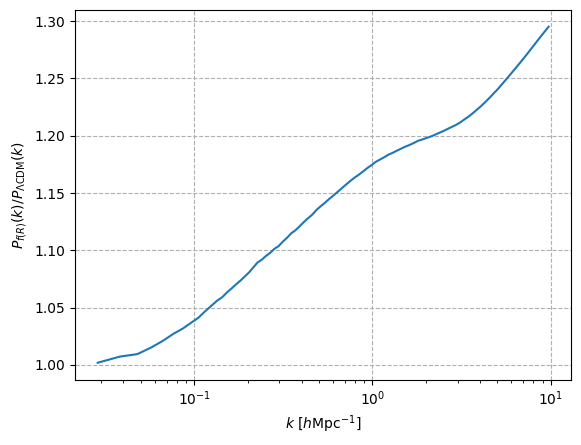

In [29]:
# Plot the boost predictions.
plt.plot(kbins, pk_boost)

plt.xscale('log')

plt.xlabel(r'$k \ \left[h\mathrm{Mpc}^{-1}\right]$')
plt.ylabel(r'$P_{f(R)}(k) / P_{\rm \Lambda CDM}(k)$')

plt.grid(True, linestyle='--')
plt.show()

- # **Custom bins; min outside, max inside range**
## Emulator predicts custom bins, safely extrapolates below


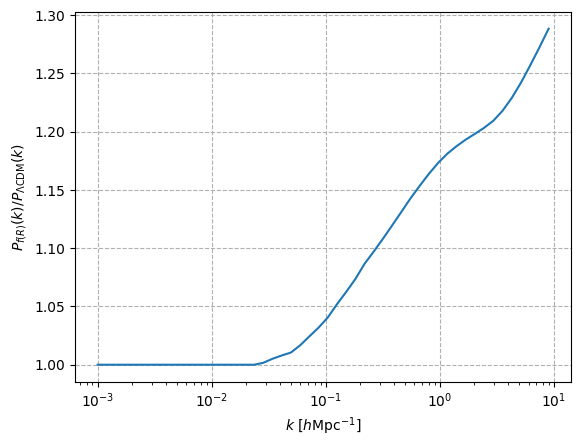

In [10]:
# Custom wavenumbre bins. The minimum value is outside the emulation range,
# while the maximum one is inside.
kbins = np.geomspace(1e-3, 9)

# Get predictions at custom wavenumber values.
pk_boost = emu.predict_boost(cosmo_params, aexp, k=kbins)

# Plot the boost predictions.
plt.plot(kbins, pk_boost)

plt.xscale('log')

plt.xlabel(r'$k \ \left[h\mathrm{Mpc}^{-1}\right]$')
plt.ylabel(r'$P_{f(R)}(k) / P_{\rm \Lambda CDM}(k)$')

plt.grid(True, linestyle='--')
plt.show()